## Ejercicio Regresión Polinómica 2

Usando los ejemplos hechos en clase debes resolver el problema que se plantea a continuación.

Usando los datos de casos confirmados de COVID-19 en el mundo frente a los días pasados desde que empezó la pandemia, haz el mejor predictor posible.



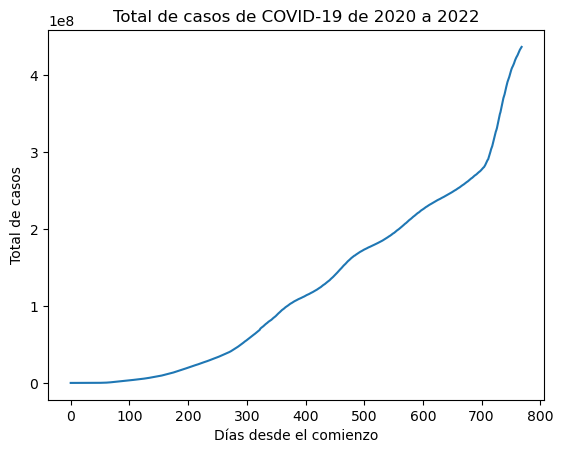

In [52]:
#Empezamos preparando los datos. Vamos a generar un dataframe con los días desde el comienzo de la 
#pandemia y el número de casos confirmados.
#Dias desde el comienzo y numero de totales en un dia
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_covid = pd.read_csv('time_series_covid19_confirmed_global.csv')
df_covid.head()

days_after_beggining = []
total_cases = []
counter = 0

#borrar columnas 
df_covid = df_covid.drop(columns=['Province/State', 'Country/Region', 'Lat', 'Long'])

#coger nombres de columnas
covid_days = df_covid.columns

#coger suma por columna
for covid_day in covid_days:
    total_cases.append(sum(df_covid[covid_day]))

#Contador de dias por numero de columnas
for days_counter in range(0,df_covid.shape[1]):
    days_after_beggining.append(counter)
    counter+=1

#Crear 
df_covid_total_cases = pd.DataFrame({
    'days after beggining' : days_after_beggining,
    'total cases' : total_cases
    })    

df_covid_total_cases.head(20)

#Grafica de datos
plt.plot(df_covid_total_cases['days after beggining'], df_covid_total_cases['total cases'])
plt.xlabel('Días desde el comienzo')
plt.ylabel('Total de casos')
plt.title('Total de casos de COVID-19 de 2020 a 2022')
plt.show()


In [53]:
#Preparamos X e y

X = df_covid_total_cases['days after beggining'].to_frame().values.reshape(-1, 1)
y = df_covid_total_cases['total cases'].to_list()




In [ ]:
#Vamos a probar con un polinomio de grado 2:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=6,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)
print(X_poly)



[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [2.00000000e+00 4.00000000e+00 8.00000000e+00 ... 1.28000000e+02
  2.56000000e+02 5.12000000e+02]
 ...
 [7.66000000e+02 5.86756000e+05 4.49455096e+08 ... 1.54739571e+20
  1.18530511e+23 9.07943715e+25]
 [7.67000000e+02 5.88289000e+05 4.51217663e+08 ... 1.56159190e+20
  1.19774099e+23 9.18667337e+25]
 [7.68000000e+02 5.89824000e+05 4.52984832e+08 ... 1.57589958e+20
  1.21029088e+23 9.29503395e+25]]


0.9935311095118371


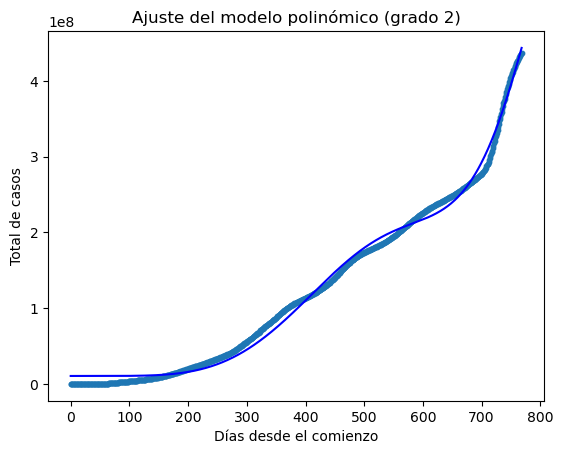

In [64]:
#Veamos que tal se ajusta a la curva:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lm = LinearRegression()
lm.fit(X_train, y_train)

# Prediccion del polinomio de grado 2
y_pred_total = lm.predict(X_poly)

# Error cuadratico medio
y_pred = lm.predict(X_test)
print(r2_score(y_test, y_pred))

# Para graficar, usamos X original (columna única) en el eje x
plt.scatter(X, y, s=10)
plt.plot(X, y_pred_total, color='blue')
plt.xlabel('Días desde el comienzo')
plt.ylabel('Total de casos')
plt.title('Ajuste del modelo polinómico (grado 2)')
plt.show()


In [ ]:
#Probemos ahora con un grado superior:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)
print(X_poly)
